In [2]:
import numpy as np
import pandas as pd
from history import Polygon
import sys
sys.path.append('/Users/moilanen/sbx/paragon/lib')
sys.path.append('/Users/moilanen/sbx/paragon/data')
sys.path.append('/Users/moilanen/sbx/paragon/data/provider')
sys.path.append('.')

# Backtester Libraries
import matplotlib.pyplot as plt
import datetime
from talib.abstract import *
import pinkfish as pf

import math
from datetime import datetime, timedelta, date

from support_resistance import sr

stocks = ['NFLX', 'AMZN']
benchmark_stock = 'QQQ' # Must be in the stocks list

_stocks = [
        'AAL',
        #'AAPL',
        'ABBV',
        'ADBE',
        'AMD',
        'AMZN',
        'AVGO',
        'BA',
        'BABA',
        'BAC',
        'BYND',
        'CAT',
        'CGC',
        'CLF',
        'COST',
        'CRM',
        'DBX',
        'DIS',
        'DKNG',
        'DOCU',
        'EDIT',
        'ETSY',
        'F',
        'FB',
        'FXI',
        'GOOGL',
        'HD',
        'HON',
        'IQ',
        'INTC',
        'IWM',
        'JD',
        'LULU',
        'LLY',
        'LYFT',
        'MSFT',
        'MU',
        'NFLX',
        'NIO',
        'NKE',
        'NKLA',
        'NOW',
        'NVDA',
        'ORCL',
        'PENN',
        'PINS',
        'PFE',
        'PM',
        'PTON',
        'PYPL',
        'QCOM',
        'QQQ',
        'ROKU',
        'SBUX',
        'SHOP',
        'SLB',
        'SNAP',
        'SPY',
        'SPCE',
        'SQ',
        'TDOC',
        'TLRY',
        # 'TSLA',
        'TTD',
        'TTWO',
        'TWLO',
        'TWTR',
        'UA',
        'UBER',
        'WMT',
        'WYNN',
        'XLF',
        'ZM',
        'ZNGA'
                  ]

_stocks = ['AAL', 'ADBE', 'AMD', 'BABA', 'C', 'AMZN', 'GOOGL', 'MSFT', 'SPCE', 'FB', 'ARKK', 'SLV', 'ZM','TWTR']


num_days = 50
capital = 100000
use_adj = True

start_date = date.today() - timedelta(days = math.ceil((num_days/(5/7))))
end_date = datetime.now()


In [3]:
# Pull Data

ohlcvs = {}
ohlcvs_daily = {}

polygon = Polygon()

if False:
    timeframe_short = '5m'
    periods_day_short = int(390/5)
else:
    timeframe_short = '30m'
    periods_day_short = int(390/30)

    
for stock in stocks:
    print("------ %s ------" % (stock))
    ohlcv = polygon.history_aggregate(stock, int(periods_day_short*num_days), timeframe_short, start_date, after_hours = True)
    ohlcvs[stock] = ohlcv

    ohlcv = polygon.history_aggregate(stock, num_days, '1d', start_date, after_hours = True)
    ohlcvs_daily[stock] = ohlcv



------ NFLX ------
------ AMZN ------


In [4]:
df = ohlcvs[stock]


In [128]:
import datetime
import pinkfish as pf

# format price data
pd.options.display.float_format = '{:0.2f}'.format

In [132]:
pf.TradeLog.cash = capital

lookback = 5

tlog = pf.TradeLog(symbol)
dbal = pf.DailyBal()

benchmark_start_date = False

for i in range(lookback, len(df)):
    for stock in stocks:
#         print(stock)
        df_tmp = df.iloc[i-lookback:i].dropna(axis=1)
        dt = df_tmp.iloc[-1].name
        last = df_tmp.iloc[-1]

        if benchmark_start_date is False:
            benchark_start_date = dt
    #     print(str(i)+" "+str(df_tmp.iloc[-1].name)+" "+str(last.close))

        if i == lookback:
            print("Buy")
            tlog.buy(dt, last.close)

        if i == len(df)-1:
            print("Sell")
            tlog.sell(dt, last.close)

        
    dbal.append(dt, last.high, last.low, last.close)

Buy
Buy
Sell
Sell


In [1]:
tlog_ = tlog.get_log()
dbal_ = dbal.get_log(tlog_)

stats = pf.stats(df, tlog_, dbal_, capital)
print("Sortino: %0.2f" % (stats.sortino_ratio))
print
print(str(pf.summary(stats)))

# pf.print_full(stats)
dbal_

NameError: name 'tlog' is not defined

# Benchmark

In [123]:
# Benchmark

pf.TradeLog.cash = capital

lookback = 5

benchmark_df = polygon.history_aggregate(benchmark_stock, int(periods_day_short*num_days), timeframe_short, start_date, after_hours = True)

benchmark_tlog = pf.TradeLog(benchmark_stock)
benchmark_dbal = pf.DailyBal()

for i in range(lookback, len(benchmark_df)):
    df_tmp = benchmark_df.iloc[i-lookback:i].dropna(axis=1)
    dt = df_tmp.iloc[-1].name
    last = df_tmp.iloc[-1]
#     print(str(i)+" "+str(df_tmp.iloc[-1].name)+" "+str(last.close))

    if i == lookback:
        print("Buy")
        benchmark_tlog.buy(dt, last.close)

    if i == len(df)-1:
        print("Sell")
        benchmark_tlog.sell(dt, last.close)
        
    benchmark_dbal.append(dt, last.high, last.low, last.close)
    

benchmark_tlog_ = benchmark_tlog.get_log()
benchmark_dbal_ = benchmark_dbal.get_log(benchmark_tlog_)


Buy
Sell


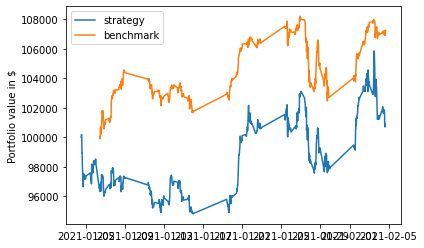

In [124]:
pf.plot_equity_curve(dbal_, benchmark=benchmark_dbal_)